Notebook dedicated to data preprocessing and exploratory analysis.

In [ ]:
import sys
import re
import unicodedata
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

import spacy

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from gensim.models.phrases import Phrases, Phraser

from wordcloud import WordCloud

import pyLDAvis
import pyLDAvis.lda_model

sys.path.append("../")

from src.preprocessing import clean_text, build_lemmatized_corpus, build_ngrams, build_preprocessed_corpus

In [97]:
#loading the dataset
ds = load_dataset("samchain/bis_central_bank_speeches", split="train")
df = ds.to_pandas()

In [96]:
df['bank'].nunique()

118

In [ ]:
# primary cleaning and filtering of the dataset
df = df[df["text"].notna()]
df = df[df["text"].str.strip() != ""]
df = df[df["text"].str.contains("[a-zA-Z]", na=False)]

df["text_length"] = df["text"].str.len()
df = df[(df["text_length"] > 500) & (df["text_length"] < 100000)]

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].notna()]
df = df[df["clean_text"].str.strip() != ""]

In [17]:
# stats
df["text_length"].describe()

count    19170.000000
mean     17420.650443
std      10635.912174
min        933.000000
25%       9600.250000
50%      15335.500000
75%      22893.750000
max      90494.000000
Name: text_length, dtype: float64

In [18]:
#median
df["text_length"].median()

np.float64(15335.5)

<Axes: >

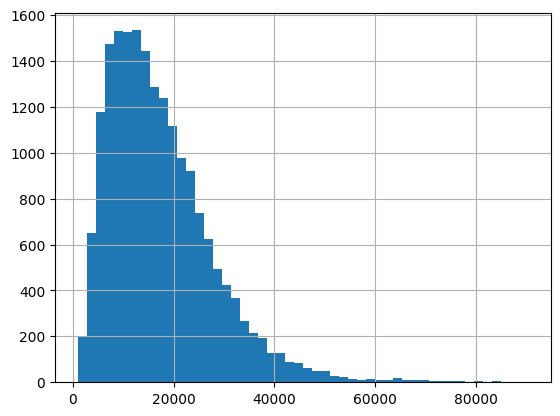

In [19]:
df["text_length"].hist(bins=50)

In [24]:
df["description"].sample(5).tolist()

['Speech by Mr Jean-Claude Trichet, President of the European Central Bank, at the Forum ABC, Madrid, 15 February 2008.',
 'Remarks by Prof. Emmanuel Tumusiime-Mutebile, Governor of the Bank of Uganda, at the International Association of Deposit Insurers - Africa Regional Committee Conference, Kigo, 16 September 2019.',
 'Interview with Dr Duvvuri Subbarao, Governor of the Reserve Bank of India, in The Wall Street Journal, conducted by Alex Frangos and originally published on WSJ online on 13 February 2012.',
 "Essay by Dr Zhou Xiaochuan, Governor of the People's Bank of China, 23 March 2009.",
 'Opening address by Dr Bandid Nijathaworn, Deputy Governor of the Bank of Thailand, at the 2nd SEACEN-OCC Advanced Seminar on Quantitative Techniques for Macro Surveillance and Determining Resilience of the Banking Sector, Bangkok, 3 September 2007.']

In [74]:
df[df["doc_type"]=="other"]["description"].sample(40).tolist()

['Contribution by Mr Jean-Claude Trichet, President of the European Central Bank, to Frankfurter Allgemeine Zeitung, Frankfurt am Main, 26 March 2010.',
 'BANK OF FRANCE, MONTHLY BUSINESS SURVEY, December 1996.',
 'BANK OF FRANCE, MONTHLY BUSINESS SURVEY, 17/3/97.',
 'BANK OF JAPAN, COMMUNICATION, 16/6/98.',
 'Bank of Japan, Communication, 15 October 1999.',
 'Contribution by Mr Jean-Claude Trichet, President of the European Central Bank, at the Panel on EU/US cooperation at the Advancing Enterprise Conference, London, 26 January 2004.',
 'Lectio Magistralis by Ms Christine Lagarde, President of the European Central Bank, at the Accademia Nazionale dei Lincei, Turin, 29 November 2021.',
 'Keynote\xa0message\xa0by Mr Eli M Remolona, Jr, Governor of Bangko Sentral ng Pilipinas (BSP,\xa0the central bank of the Philippines), at the 2024 Annual Reception for the Banking Community, Manila,\xa010 January 2025.',
 'Message by Mr Benjamin E Diokno, Governor of Bangko Sentral ng Pilipinas (BSP, 

In [ ]:
def get_doc_type(desc):
    if not isinstance(desc, str):
        return "other"
    desc = desc.lower()
    if "speech" in desc:
        return "speech"
    elif "remarks" in desc:
        return "remarks"
    elif "address" in desc:
        return "address"
    elif "interview" in desc:
        return "interview"
    elif "lecture" in desc:
        return "lecture"
    elif "statement" in desc:
        return "statement"
    elif "presentation" in desc:
        return "presentation"
    elif "note" in desc or "speaking" in desc:
        return "note"
    elif "keynote" in desc:
        return "keynote"
    elif "paper" in desc:
        return "paper"
    elif "report" in desc:
        return "report"
    elif "hearing" in desc:
        return "hearing"
    elif "message" in desc:
        return "message"
    elif "letter" in desc:
        return "letter"
    elif "transcript" in desc:
        return "transcript"
    elif "comment" in desc:
        return "comment"
    else:
        return "other"

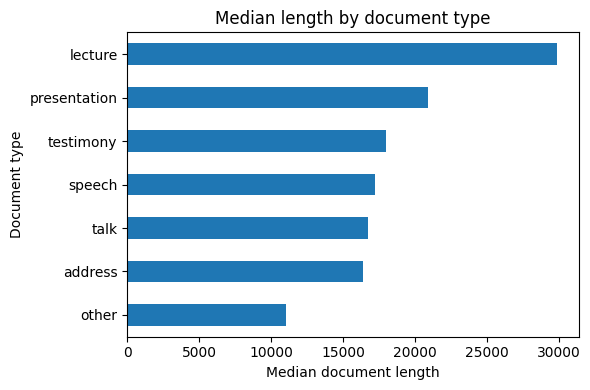

In [47]:
counts = df.groupby("doc_type")["text_length"].median()
top = counts.sort_values(ascending=False).head(6)
others = counts.drop(top.index).mean()
top["other"] = others
top.sort_values().plot(kind="barh", figsize=(6,4))
plt.xlabel("Median document length")
plt.ylabel("Document type")
plt.title("Median length by document type")
plt.tight_layout()
plt.show()

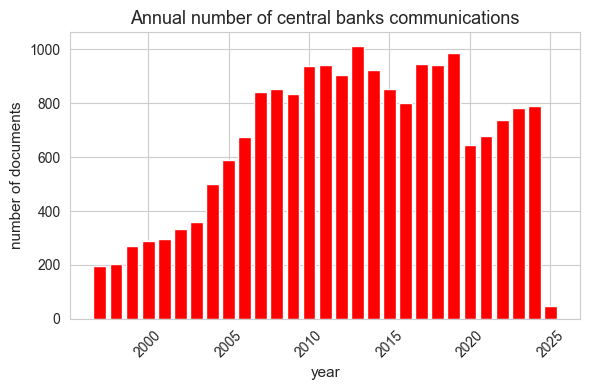

In [59]:
sns.set_style("whitegrid")
counts = df.groupby("Year").size()
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color="red")
plt.title("Annual number of central banks communications", fontsize=13)
plt.xlabel("year", fontsize=11)
plt.ylabel("number of documents", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

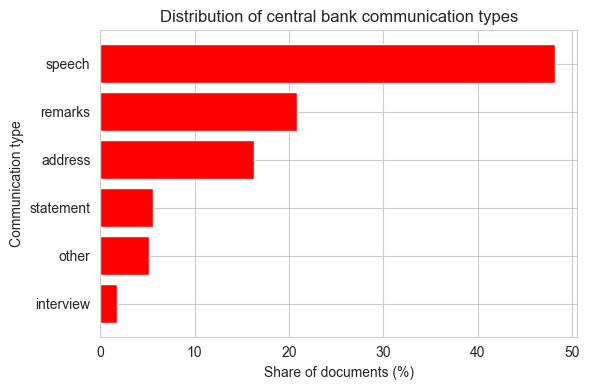

In [73]:
type_dist = df["doc_type"].value_counts(normalize=True) * 100
top_k = 6
top_types = type_dist.nlargest(top_k)
other = type_dist.drop(top_types.index).sum()
top_types["other"] = other
top_types = top_types.sort_values()
plt.figure(figsize=(6,4))
plt.barh(top_types.index, top_types.values, color="red")
plt.xlabel("Share of documents (%)")
plt.ylabel("Communication type")
plt.title("Distribution of central bank communication types")
plt.tight_layout()
plt.show()

In [ ]:
# tuning n-grams thresholds - compare ratio & avg_freq - final choice : threshold = 15

thresholds = [10, 15, 20]
ratios = []
avg_freqs = []

for th in thresholds:
    bigram = Phrases(df["tokens_lemma"], min_count=5, threshold=th)
    trigram = Phrases(bigram[df["tokens_lemma"]], threshold=th)

    bigram_mod = Phraser(bigram)
    trigram_mod = Phraser(trigram)

    tokens = df["tokens_lemma"].apply(lambda x: trigram_mod[bigram_mod[x]])

    total_tokens = sum(len(doc) for doc in tokens)
    ngrams = [w for doc in tokens for w in doc if "_" in w]

    ratio = len(ngrams) / total_tokens if total_tokens else 0

    counts = Counter(ngrams)
    avg_freq = (sum(counts.values()) / len(counts)) if counts else 0

    ratios.append(ratio)
    avg_freqs.append(avg_freq)

    print(f"TH={th} | ratio={ratio:.3f} | avg_freq={avg_freq:.2f}")
    print("TOP:", counts.most_common(10), "\n")


We track the evolution of the corpus across preprocessing steps by monitoring total and unique token counts.

In [82]:
def count_stats(texts):
    tokens = [w for doc in texts for w in doc]
    return len(tokens), len(set(tokens))

In [ ]:
# fully processed corpus
dfe = pd.read_pickle("../data/preprocessed/df_preprocessed_CB_corpus.pkl")

In [91]:
stats = {}
raw_tokens = dfe["text"].apply(lambda x: x.split())
stats["Raw text"] = count_stats(raw_tokens)
clean_tokens = dfe["clean_text"].apply(lambda x: x.split())
stats["Cleaned text"] = count_stats(clean_tokens)
stats["Remove stopwords"] = count_stats(dfe["tokens_clean"])
stats["Lemmatization"] = count_stats(dfe["tokens_lemma"])
stats["Bigrams and trigrams"] = count_stats(dfe["tokens_final"])

In [92]:
table = pd.DataFrame(stats, index=["Total words", "Unique words"])
table

,Raw text,Cleaned text,Remove stopwords,Lemmatization,Bigrams and trigrams
Total words,52428926,41730437,24735682,24753703,22196704
Unique words,679902,138281,137746,126661,167689
